In [29]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
import matplotlib.pyplot as plt

In [31]:
# Load the dataset
data = pd.read_csv('cleandataPune.csv')

In [32]:
# Display the first few rows of the dataset
print(data.head())

        size  total_sqft  bath   price    site_location  bhk  price_per_sqft
0      2 BHK      1056.0   2.0   39.07      Alandi Road    2     3699.810606
1  4 Bedroom      2600.0   5.0  120.00  Ambegaon Budruk    4     4615.384615
2      3 BHK      1440.0   2.0   62.00       Anandnagar    3     4305.555556
3      3 BHK      1521.0   3.0   95.00            Aundh    3     6245.890861
4      2 BHK      1200.0   2.0   51.00       Aundh Road    2     4250.000000


In [33]:
# Preprocess the data: Selecting relevant features and target variable
features = data[['total_sqft', 'bath', 'bhk', 'site_location']]
target = data['price']

In [34]:
# Convert categorical variable 'site_location' to numerical using one-hot encoding
features = pd.get_dummies(features, columns=['site_location'], drop_first=True)

In [35]:
# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

In [36]:
# Create a Decision Tree Regressor model
model = DecisionTreeRegressor(random_state=42)

In [37]:
# Fit the model to the training data
model.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [38]:
# Print the number of leaf nodes in the tree
print(f"Number of leaf nodes: {model.get_n_leaves()}")

Number of leaf nodes: 9212


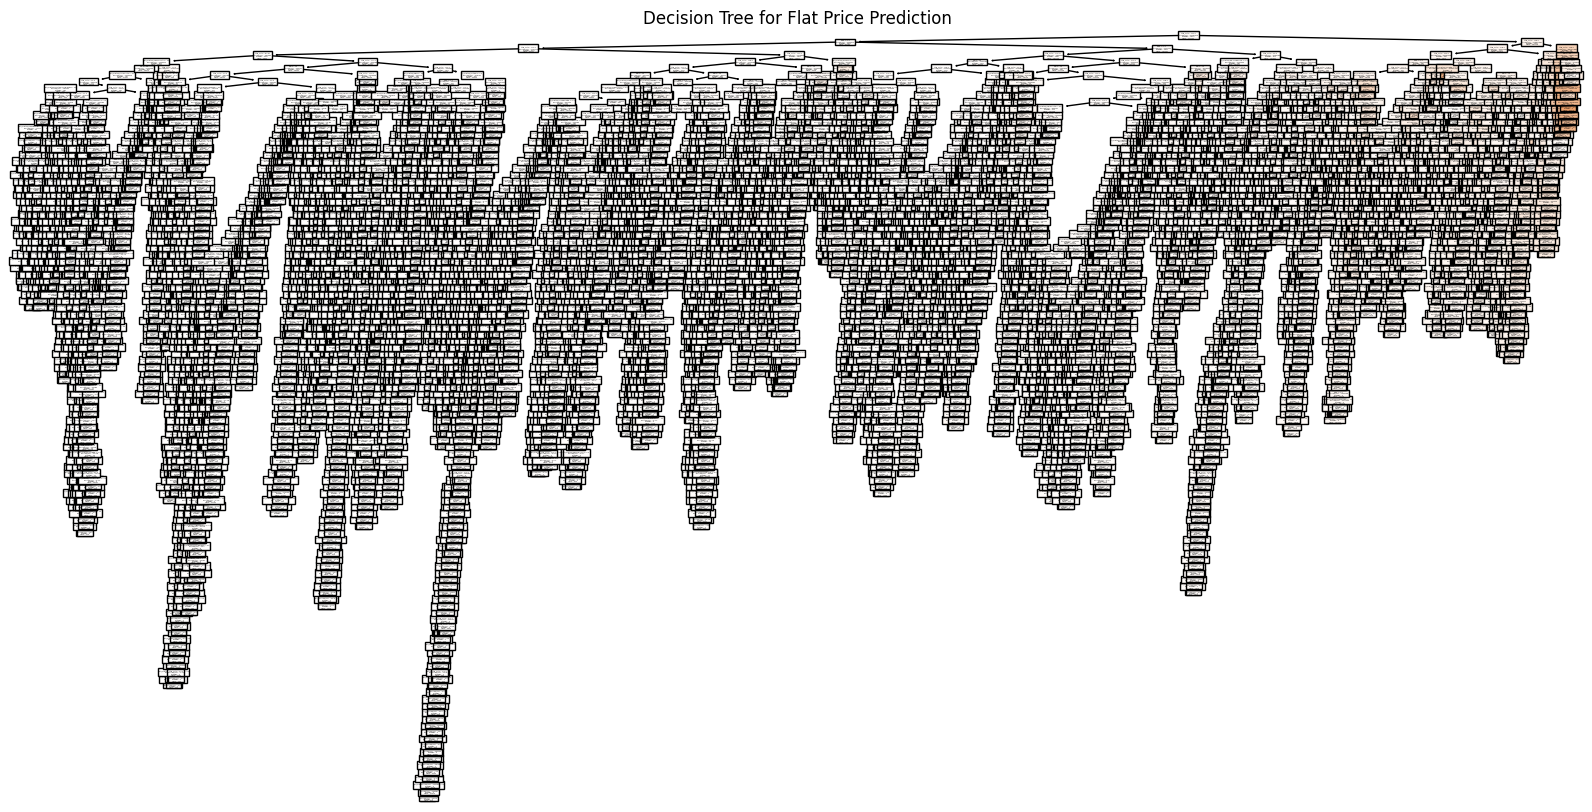

In [39]:
# Visualize the decision tree
plt.figure(figsize=(20,10))
plot_tree(model, feature_names=features.columns, filled=True)
plt.title("Decision Tree for Flat Price Prediction")
plt.show()

In [40]:
# Function to predict flat price based on area, number of rooms, bathrooms, and location
def predict_flat_price(area, rooms, bathrooms, location):
    # Prepare input data with one-hot encoding for location
    input_data = [[area, bathrooms, rooms] + [1 if loc == location else 0 for loc in features.columns if loc.startswith('site_location_')]]
    predicted_price = model.predict(input_data)
    return predicted_price[0]


In [43]:
# Example prediction
area = 1000  # example area in sqft
rooms = 2    # example number of rooms (BHK)
bathrooms = 2  # example number of bathrooms
location = 'Kasba Peth'  # example location

In [44]:
predicted_price = predict_flat_price(area, rooms, bathrooms, location)
print(f"The predicted flat price for an area of {area} sqft with {rooms} BHK and {bathrooms} bathrooms in {location} is: {predicted_price:.2f}")

The predicted flat price for an area of 1000 sqft with 2 BHK and 2 bathrooms in Kasba Peth is: 41.50


C:\Users\vaish\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
